In [1]:
# --- CELL 1: Import Necessary Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# --- CELL 2: Import credit.csv File ---
df = pd.read_csv('credit.csv')

In [3]:
# --- CELL 3: EDA Process
df.head()

,observation_id,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,...,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job,gender
0,0,-43.0,6,critical,radio/tv,1169,NaN,13 years,4,single,...,67,none,own,2,0,1,2.349340e+09,yes,skilled employee,male
1,1,75.0,48,repaid,radio/tv,5951,89.0,2 years,2,NaN,...,22,none,own,1,1,1,NaN,yes,skilled employee,female
2,2,NaN,12,critical,education,2096,24.0,5 years,2,single,...,49,none,own,1,0,2,NaN,yes,unskilled resident,male
3,3,-32.0,42,repaid,furniture,7882,9.0,5 years,2,single,...,45,none,for free,1,0,2,NaN,yes,skilled employee,male
4,4,-23.0,24,delayed,car (new),4870,43.0,3 years,3,single,...,53,none,for free,2,1,2,NaN,yes,skilled employee,male


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   observation_id        1000 non-null   int64  
 1   checking_balance      606 non-null    float64
 2   months_loan_duration  1000 non-null   int64  
 3   credit_history        1000 non-null   object 
 4   purpose               1000 non-null   object 
 5   amount                1000 non-null   int64  
 6   savings_balance       817 non-null    float64
 7   employment_length     938 non-null    object 
 8   installment_rate      1000 non-null   int64  
 9   personal_status       690 non-null    object 
 10  other_debtors         1000 non-null   object 
 11  residence_history     870 non-null    object 
 12  property              1000 non-null   object 
 13  age                   1000 non-null   int64  
 14  installment_plan      1000 non-null   object 
 15  housing               

In [5]:
df.shape

(1000, 23)

In [6]:
df.isnull().sum()

observation_id            0
checking_balance        394
months_loan_duration      0
credit_history            0
purpose                   0
amount                    0
savings_balance         183
employment_length        62
installment_rate          0
personal_status         310
other_debtors             0
residence_history       130
property                  0
age                       0
installment_plan          0
housing                   0
existing_credits          0
default                   0
dependents                0
telephone               596
foreign_worker            0
job                       0
gender                    0
dtype: int64

In [7]:
df = df.drop(columns=['observation_id', 'telephone'])

# Converting text durations (years/months) to numerical values
def convert_to_years(val):
    if pd.isna(val): return np.nan
    val = str(val).lower()
    if 'year' in val: return float(val.split()[0])
    elif 'month' in val: return float(val.split()[0]) / 12
    return np.nan

df['employment_length'] = df['employment_length'].apply(convert_to_years)
df['residence_history'] = df['residence_history'].apply(convert_to_years)

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encoding categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Splitting data 
X = df_encoded.drop('default', axis=1)
y = df_encoded['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19, stratify=y)

# Feature Scaling (Needed for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Helper function for Confusion Matrix visualization
def plot_confusion_matrix(y_true, y_pred, title, color='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


--- Logistic Regression ---


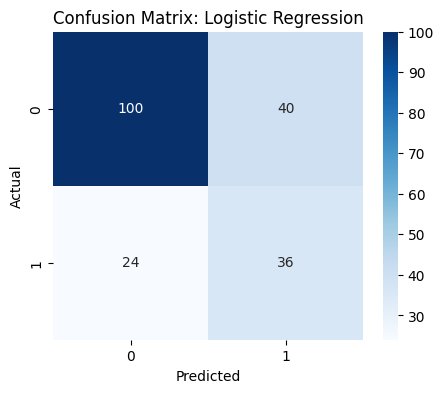

In [8]:
# --- CELL 5: Logistic Regression & Confusion Matrix ---
lr = LogisticRegression(class_weight='balanced', random_state=19)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("\n--- Logistic Regression ---")
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")


--- Decision Tree ---


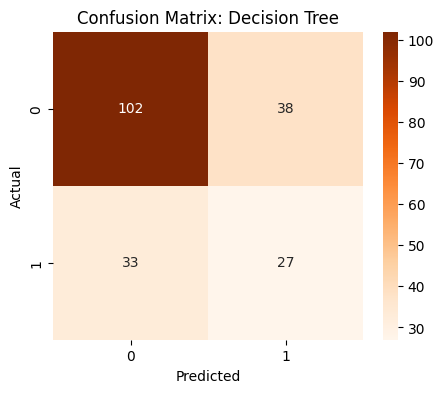

In [9]:
# --- CELL 6: Decision Tree & Confusion Matrix ---
dt = DecisionTreeClassifier(class_weight='balanced', random_state=19)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("\n--- Decision Tree ---")
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree", color='Oranges')


--- Random Forest (Baseline) ---


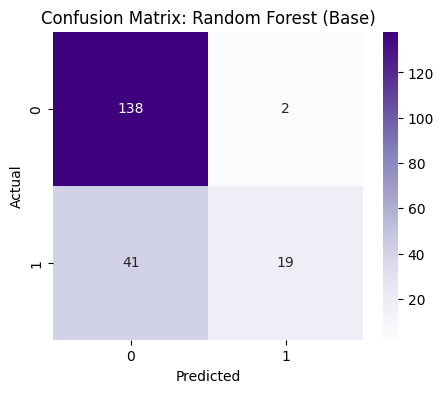

In [10]:
# --- CELL 7: Random Forest (Baseline) & Confusion Matrix ---
rf_base = RandomForestClassifier(class_weight='balanced', random_state=19)
rf_base.fit(X_train, y_train)
y_pred_rf_base = rf_base.predict(X_test)
print("\n--- Random Forest (Baseline) ---")
plot_confusion_matrix(y_test, y_pred_rf_base, "Random Forest (Base)", color='Purples')


--- SVM ---


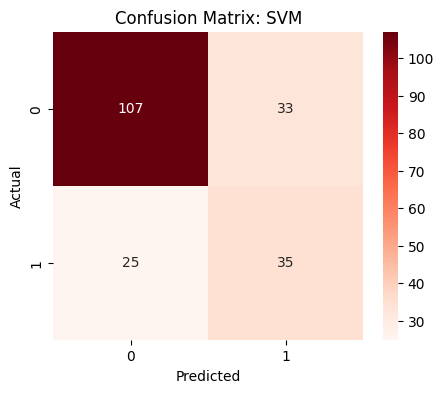

In [11]:
# --- CELL 8: SVM & Confusion Matrix ---
svm = SVC(class_weight='balanced', random_state=19)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("\n--- SVM ---")
plot_confusion_matrix(y_test, y_pred_svm, "SVM", color='Reds')


---  Random Forest  ---


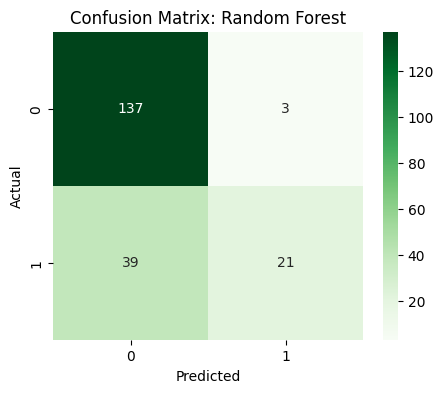

In [12]:

# --- CELL 9: Random Forest  ---
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=12, 
    min_samples_split=5, 
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_opt = rf.predict(X_test)
print("\n---  Random Forest  ---")
plot_confusion_matrix(y_test, y_pred_opt, "Random Forest", color='Greens')

In [13]:
# --- CELL 10: Conclusion & Best Model Detailed Working ---
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest (Base)": accuracy_score(y_test, y_pred_rf_base),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_opt)
}

print("\n--- MODEL PERFORMANCE SUMMARY ---")
for model, acc in results.items():
    print(f"{model} Accuracy: {acc:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nCONCLUSION: The best model is {best_model_name}")
print("\n--- DETAILED WORKING OF BEST MODEL ---")
print(classification_report(y_test, y_pred_opt))


--- MODEL PERFORMANCE SUMMARY ---
Logistic Regression Accuracy: 0.6800
Decision Tree Accuracy: 0.6450
Random Forest (Base) Accuracy: 0.7850
SVM Accuracy: 0.7100
Random Forest Accuracy: 0.7900

CONCLUSION: The best model is Random Forest

--- DETAILED WORKING OF BEST MODEL ---
              precision    recall  f1-score   support

           0       0.78      0.98      0.87       140
           1       0.88      0.35      0.50        60

    accuracy                           0.79       200
   macro avg       0.83      0.66      0.68       200
weighted avg       0.81      0.79      0.76       200

